Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [13]:
%%capture
!pip install watermark
!pip install torchinfo datasets pytorch-crf
!pip install -U datasets

In [14]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch,datasets

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch   : 2.9.0+cu126
datasets: 4.8.3



# Bidirectional LSTM + CRF for Named Entity Recognition (NER)

This notebook implements a robust **Token Classification** architecture. Unlike Seq2Seq, which generates a new sequence, NER assigns a specific label to every token in the input. We utilize a **Bidirectional LSTM** to capture context from both directions and a **Conditional Random Field (CRF)** layer to ensure logical label sequences (e.g., preventing an `I-PER` from following a `B-LOC`).


**Network Architecture:**
1. **The Embedding Layer:** Converts tokens into dense vectors.
2. **The Bi-LSTM:** Processes the sentence forward and backward, concatenating the results to understand if "Apple" is a fruit or a company based on surrounding words.
3. **The CRF Layer:** Models the dependencies between output tags, enforcing the IOB (Inside, Outside, Beginning) schema.

---
### **Key Concepts of NER Architecture:**
1. **Token-Level Prediction:** The input length exactly matches the output length ($N \to N$).
2. **IOB Tagging:** Handles multi-word entities (e.g., "New" = `B-LOC`, "York" = `I-LOC`).
3. **Context Windows:** Using Bi-LSTMs allows the model to "see the future" of the sentence to better classify the current word.
4. **Transition Matrices:** The CRF learns which tag transitions are likely (e.g., `B-PER` $\to$ `I-PER`) and which are impossible.

---
### The Conditional Random Field (CRF) Layer

The CRF layer sits on top of our Bi-LSTM emissions (logits). It maintains a learned **Transition Matrix** of size `[NUM_TAGS, NUM_TAGS]`. 

For example, if we have tags `[O, B-PER, I-PER, B-LOC]`, the CRF learns transition scores like:
| From \ To | O | B-PER | I-PER | B-LOC |
| :--- | :--- | :--- | :--- | :--- |
| **O** | High | High | **-1000 (Invalid)** | High |
| **B-PER** | High | Low | **High (Valid)** | Low |

Instead of `CrossEntropyLoss`, the CRF computes the **Negative Log-Likelihood** of the entire sequence of tags. During inference, it uses **Viterbi Decoding** to find the globally optimal path through the transition matrix.

---
### 🏷️ Named Entity Recognition (NER)

Named Entity Recognition is a **Sequence Tagging** task where the goal is to assign a label (e.g., Person, Organization, Location) to every token in a sentence. Unlike sentiment classification (Many-to-One), NER requires the model to maintain a 1:1 mapping between input and output while capturing global dependencies between labels.

#### The OOV Challenge: Why Character-CNNs?
In standard Word-Level models, an unknown word (OOV) like **"Elon"** or **"Tottenham"** is mapped to a generic `<UNK>` token, losing all semantic meaning. By adding a **Character-level CNN**, the model learns to "look inside" the word:
* **Prefixes/Suffixes:** Recognizes that words ending in *-chester* are likely locations.
* **Capitalization:** Identifies that Title Case words are likely entities, even if the word isn't in the 20k vocabulary.
* **Morphology:** Captures structural patterns that allow the model to guess the correct tag for unseen names.

#### The CRF "Brain"
While the Bi-LSTM provides rich contextual features, the **Conditional Random Field (CRF)** layer acts as the sequence optimizer. It learns a transition matrix that forbids "illegal" sequences (e.g., an `I-PER` tag cannot follow a `B-LOC` tag), ensuring the final output is grammatically and logically consistent.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Sampler, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary
from torchcrf import CRF


import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [16]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [17]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.0005    # 0.001
# NUM_EPOCHS = 10          # News topics usually converge faster than char-level text
# NUM_CLASSES = 4        # [World, Sports, Business, Sci/Tech]

# Vocabulary & Architecture
VOCABULARY_SIZE = 20000 
EMBEDDING_DIM = 128
HIDDEN_DIM = 128 #256
DROPOUT_P = 0.5        # Crucial for Stacked architectures to prevent overfitting

# Sequence Constraints
# MAX_LEN = 100          # AG News sentences are shorter than Wikipedia/Shakespeare chunks
# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [18]:
# 1. Load CoNLL2003 NER Dataset
raw_datasets = load_dataset("lhoestq/conll2003")

# 2. Extract Tag Mappings
# CoNLL2003 has 9 standard tags (O, B-PER, I-PER, B-ORG, I-ORG, B-LOC, I-LOC, B-MISC, I-MISC)
tag_names = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
# tag_names = raw_datasets["train"].features["ner_tags"].feature.names
NUM_TAGS = len(tag_names)
tag2idx = {tag: i for i, tag in enumerate(tag_names)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

print(f"Dataset Loaded . Number of Tags: {NUM_TAGS}")
print(f"Tags: {tag_names}")
print(f"Mapping Check: {tag2idx['B-PER']} -> B-PER")

# 3. Build Word Vocabulary
# Note: Lowercasing is standard for basic NER to reduce vocab size
word_counts = Counter()
for tokens in raw_datasets['train']['tokens']:
    word_counts.update([t.lower() for t in tokens])

VOCABULARY_SIZE = 20000
vocab = {'<PAD>': 0, '<UNK>': 1}
for i, (word, _) in enumerate(word_counts.most_common(VOCABULARY_SIZE - 2)):
    vocab[word] = i + 2

print(f"Word Vocabulary Size: {len(vocab)}")

# Build Char Vocab from the training set tokens
all_chars = set([char for tokens in raw_datasets['train']['tokens'] for word in tokens for char in word])
char_vocab = {'<PAD>': 0, '<UNK>': 1}
for i, char in enumerate(sorted(list(all_chars))):
    char_vocab[char] = i + 2

CHAR_VOCAB_SIZE = len(char_vocab)
MAX_WORD_LEN = 15 # Standard for English; covers most names/places
print(f"Character Vocabulary Size: {CHAR_VOCAB_SIZE}")

Dataset Loaded . Number of Tags: 9
Tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Mapping Check: 1 -> B-PER
Word Vocabulary Size: 20000
Character Vocabulary Size: 86


In [19]:
# Pick a random sample and check if the tags make sense
sample = raw_datasets["train"][4] # Usually a sentence about "Germany" or "European Commission"
print("Tokens:", sample["tokens"])
print("Tags:  ", [idx2tag[t] for t in sample["ner_tags"]])

Tokens: ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Tags:   ['B-LOC', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [29]:
# Create a small sample batch from the training set
sample_data = []
for i in range(4):
    tokens = raw_datasets['train']['tokens'][i]
    labels = raw_datasets['train']['ner_tags'][i]
    sample_data.append((tokens, labels))

# Test the collate function
try:
    test_loader = DataLoader(sample_data, batch_size=4, collate_fn=ner_collate_fn)
    words, chars, labels, lengths = next(iter(test_loader))
    
    print("--- Shape Audit ---")
    print(f"Words (2D): {words.shape}  -> [Batch, Seq_Len]")
    print(f"Chars (3D): {chars.shape} -> [Batch, Seq_Len, Max_Word_Len]")
    print(f"Labels:     {labels.shape}")
    print(f"Lengths:    {lengths.tolist()}")
    print("\nAudit Passed: Tensors are ready for NER_CRF.")
except Exception as e:
    print(f"Audit Failed: {e}")

--- Shape Audit ---
Words (2D): torch.Size([4, 30])  -> [Batch, Seq_Len]
Chars (3D): torch.Size([4, 30, 15]) -> [Batch, Seq_Len, Max_Word_Len]
Labels:     torch.Size([4, 30])
Lengths:    [9, 2, 2, 30]

Audit Passed: Tensors are ready for NER_CRF.


In [22]:
class NERTexDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # Tokens are strings, ner_tags are already integers (0-8)
        return self.data[idx]['tokens'], self.data[idx]['ner_tags']

class BucketSampler(Sampler):
    def __init__(self, data_source, batch_size, shuffle=True):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = sorted(range(len(data_source)), key=lambda i: len(data_source[i][0]))

    def __iter__(self):
        batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]
        if self.shuffle:
            random.shuffle(batches)
        return iter([idx for batch in batches for idx in batch])

    def __len__(self):
        return len(self.data_source)

def ner_collate_fn(batch):
    text_list, char_list, label_list, lengths = [], [], [], []

    for _text, _label in batch:
        # 1. Word Numericalization
        word_ids = [vocab.get(t.lower(), 1) for t in _text]
        text_list.append(torch.tensor(word_ids, dtype=torch.long))
        
        # 2. Character Numericalization (The 3D part)
        batch_char_ids = []
        for word in _text:
            # Truncate or pad each word to MAX_WORD_LEN
            c_ids = [char_vocab.get(c, 1) for c in word][:MAX_WORD_LEN]
            c_ids += [0] * (MAX_WORD_LEN - len(c_ids))
            batch_char_ids.append(c_ids)
        char_list.append(torch.tensor(batch_char_ids, dtype=torch.long))
        
        label_list.append(torch.tensor(_label, dtype=torch.long))
        lengths.append(len(word_ids))

    # Pad Sequences
    words_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    labels_padded = pad_sequence(label_list, batch_first=True, padding_value=-100)
    
    # Pad the 3D char tensor [Batch, Seq_Len, Max_Word_Len]
    chars_padded = pad_sequence(char_list, batch_first=True, padding_value=0)
    
    return words_padded.to(DEVICE), chars_padded.to(DEVICE), labels_padded.to(DEVICE), torch.tensor(lengths)

# Initialize
train_ds = NERTexDataset(raw_datasets['train'])
val_ds   = NERTexDataset(raw_datasets['validation'])
test_ds = NERTexDataset(raw_datasets['test'])

# Using your BucketSampler for efficiency
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, 
                          sampler=BucketSampler(train_ds, BATCH_SIZE), 
                          collate_fn=ner_collate_fn)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                        collate_fn=ner_collate_fn)

test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=ner_collate_fn)

---
# 2. Model Creation

---


In [25]:
class CharCNNEmbedding(nn.Module):
    def __init__(self, char_vocab_size, char_embed_dim, word_out_dim, kernel_size=3):
        super().__init__()
        # 1. Embed each character
        self.char_embed = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=0)
        
        # 2. Extract features from character sequences (n-grams)
        self.conv = nn.Conv1d(char_embed_dim, word_out_dim, kernel_size=kernel_size, padding=kernel_size//2)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, max_word_len]
        batch_size, seq_len, max_word_len = x.shape
        
        # Flatten to treat every word in the batch as an independent sample for the CNN
        x = x.view(-1, max_word_len) # [batch*seq, max_word_len]
        
        embedded = self.char_embed(x).transpose(1, 2) # [batch*seq, char_embed_dim, max_word_len]
        
        # Apply convolution and Global Max Pooling
        features = torch.relu(self.conv(embedded))
        word_repr, _ = torch.max(features, dim=2) # [batch*seq, word_out_dim]
        
        # Reshape back to sequence format
        return word_repr.view(batch_size, seq_len, -1)

class RobustBiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, char_vocab_size, word_dim, char_dim, char_out_dim, hidden_size, num_tags, pad_idx=0, dropout_p=0.5):
        super().__init__()
        self.word_embed = nn.Embedding(vocab_size, word_dim, padding_idx=pad_idx)
        self.char_module = CharCNNEmbedding(char_vocab_size, char_dim, char_out_dim)
        
        # Input to LSTM is (Word Embedding + Char Feature)
        combined_dim = word_dim + char_out_dim
        
        self.lstm = nn.LSTM(combined_dim, hidden_size, num_layers=2, 
                            bidirectional=True, batch_first=True, dropout=dropout_p)
        
        self.classifier = nn.Linear(hidden_size * 2, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, words, chars, lengths, labels=None):
        w_emb = self.word_embed(words)
        c_emb = self.char_module(chars)
        
        # Concatenate features
        x = torch.cat([w_emb, c_emb], dim=-1)
        
        # Rest of the Bi-LSTM + CRF logic remains the same...
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        
        emissions = self.classifier(lstm_out)
        mask = (words != 0)
        
        if labels is not None:
            clean_labels = labels.clone()
            clean_labels[clean_labels == -100] = 0
            return -self.crf(emissions, clean_labels, mask=mask, reduction='mean')
        return self.crf.decode(emissions, mask=mask)

In [30]:
set_all_seeds(RANDOM_SEED)

# Initialize the upgraded model
# 1. Define your hyperparameters clearly
WORD_DIM = 100
CHAR_DIM = 25
CHAR_OUT_DIM = 50
HIDDEN_DIM = 256
DROPOUT_P = 0.5

# 2. Initialize using named arguments
model_crf = RobustBiLSTM_CRF(
    vocab_size=len(vocab),
    char_vocab_size=len(char_vocab),
    word_dim=WORD_DIM,
    char_dim=CHAR_DIM,
    char_out_dim=CHAR_OUT_DIM,
    hidden_size=HIDDEN_DIM,
    num_tags=len(tag_names),
    pad_idx=vocab['<PAD>'],
    dropout_p=DROPOUT_P
).to(DEVICE)

print("Model initialized successfully with Character CNN and CRF layers.")

Model initialized successfully with Character CNN and CRF layers.


In [34]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Safely get components using your NEW attribute names
    word_emb_params = sum(p.numel() for p in model.word_embed.parameters())
    char_module_params = sum(p.numel() for p in model.char_module.parameters())
    lstm_params = sum(p.numel() for p in model.lstm.parameters())
    classifier_params = sum(p.numel() for p in model.classifier.parameters())
    crf_params = sum(p.numel() for p in model.crf.parameters())
    
    print(f"--- NER Model Parameter Audit ---")
    print("-" * 35)
    print(f"{'Component':<20} | {'Parameters':<12}")
    print("-" * 35)
    print(f"{'Word Embedding':<20} | {word_emb_params:,}")
    print(f"{'Char CNN Module':<20} | {char_module_params:,}")
    print(f"{'Bi-LSTM':<20} | {lstm_params:,}")
    print(f"{'Classifier Head':<20} | {classifier_params:,}")
    print(f"{'CRF Layer':<20} | {crf_params:,}")
    print("-" * 35)
    print(f"{'TOTAL TRAINABLE':<20} | {total:,}")


count_parameters(model_crf)

--- NER Model Parameter Audit ---
-----------------------------------
Component            | Parameters  
-----------------------------------
Word Embedding       | 2,000,000
Char CNN Module      | 5,950
Bi-LSTM              | 2,412,544
Classifier Head      | 4,617
CRF Layer            | 99
-----------------------------------
TOTAL TRAINABLE      | 4,423,210


---
# 3. Model Training, Testing & Evaluation

---

In [56]:
def evaluate_model(model, data_loader, device, tag_names=None, plot=False, hide_outside=False):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        # Notice we now unpack 4 items from the data_loader
        for words, chars, labels, lengths in data_loader:
            words = words.to(device)
            chars = chars.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)
            
            # 1. Inference: Get Viterbi paths 
            # Passing both word and char tensors
            batch_preds = model(words, chars, lengths)
            
            # 2. Loss: Get Negative Log Likelihood
            loss = model(words, chars, lengths, labels=labels)
            total_loss += loss.item() * words.size(0)
            
            # 3. Masking: Extract only real tokens
            for i in range(words.size(0)):
                seq_len = lengths[i].item()
                real_labels = labels[i, :seq_len].cpu().numpy().tolist()
                
                all_preds.extend(batch_preds[i])
                all_labels.extend(real_labels)

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    if plot:
        print(f"Loss: {avg_loss:.4f} | Accuracy: {acc:.2%} | Macro F1: {f1:.2%}")
        if tag_names:
            report_labels = list(range(len(tag_names)))
            report_targets = tag_names
            if hide_outside:
                o_idx = tag_names.index("O")
                report_labels = [i for i in report_labels if i != o_idx]
                report_targets = [t for i, t in enumerate(tag_names) if i != o_idx]
            
            print(f"\nClassification Report (Hide Outside={hide_outside}):\n")
            print(classification_report(all_labels, all_preds, labels=report_labels, target_names=report_targets, zero_division=0))
            
            cm = confusion_matrix(all_labels, all_preds, labels=report_labels)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=report_targets, yticklabels=report_targets)
            plt.title(f'NER Confusion Matrix (Excluding Outside: {hide_outside})')
            plt.show()

    return avg_loss, acc, f1

In [48]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs, device, 
                       tag_names=None, patience=5):
    
    # --- 1. PERFORMANCE & EARLY STOPPING INIT ---
    scaler = torch.amp.GradScaler('cuda')
    start_time = time.time()
    best_val_f1 = 0.0
    epochs_no_improve = 0 
    
    history = {
        'train_loss': [], 'val_loss': [], 'train_acc': [],
        'val_acc': [], 'val_f1': [], 'lrs': []
    }

    print(f"Starting NER training on {device} (Patience: {patience})...")

    for epoch in range(num_epochs):
        # --- 2. TRAINING PHASE ---
        model.train()
        train_running_loss = 0.0
        train_total_samples = 0
        train_correct = 0
        train_total_tokens = 0

        # Unpacking 4 items: words, chars, labels, lengths
        for words, chars, labels, lengths in train_loader:
            words = words.to(device, non_blocking=True)
            chars = chars.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            lengths = lengths.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                # Pass both words and chars to the model
                loss = model(words, chars, lengths, labels=labels)

            scaler.scale(loss).backward()
            
            # Unscale and clip for Bi-LSTM stability
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()

            train_running_loss += loss.item() * words.size(0)
            train_total_samples += words.size(0)
            
            with torch.no_grad():
                batch_preds = model(words, chars, lengths)
                for i in range(words.size(0)):
                    seq_len = lengths[i].item()
                    # Compare predictions to real labels (ignoring padding)
                    pred = batch_preds[i]
                    target = labels[i, :seq_len].cpu().numpy().tolist()
                    
                    train_correct += sum(p == t for p, t in zip(pred, target))
                    train_total_tokens += seq_len
        
        epoch_train_acc = train_correct / train_total_tokens


        # --- 3. VALIDATION PHASE ---
        epoch_train_loss = train_running_loss / train_total_samples
        
        # Using the updated ultimate evaluation function
        epoch_val_loss, epoch_val_acc, epoch_val_f1 = evaluate_ultimate_ner(
            model, val_loader, device, tag_names=tag_names, plot=False
        )

        # --- 4. EARLY STOPPING & CHECKPOINT LOGIC ---
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            torch.save(model.state_dict(), 'best_ultimate_ner.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        # --- 5. LOGGING ---
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['val_f1'].append(epoch_val_f1)
        history['lrs'].append(current_lr)

        print(f'Epoch {epoch + 1:03d}/{num_epochs:03d} | '
              f'Acc (T/V): {epoch_train_acc:.2%} / {epoch_val_acc:.2%} | '
              f'Val F1: {epoch_val_f1:.2%} | '
              f'Loss (T/V): {epoch_train_loss:.4f} / {epoch_val_loss:.4f} | '
              f'LR: {current_lr:.6f}{status_msg}')

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break

    total_time = (time.time() - start_time) / 60
    print(f'\nDone! Total Time: {total_time:.2f} min | Best Val F1: {best_val_f1:.2%}')
    
    model.load_state_dict(torch.load('best_ultimate_ner.pth'))
    return history

In [49]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Check for all possible metrics
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history
    has_gen = 'val_ppl' in history
    
    # Universal plots: Loss + Learning Rate = 2
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss (Universal) ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='#ff7f0e')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy (%) ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train Acc', color='#1f77b4')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's--', label='Val Acc', color='#ff7f0e')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score (%) ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='#2ca02c')
        plt.title('F1 Score (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics (Dual Axis) ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()
        
        # Perplexity (Purple)
        ax1.plot(epochs, history['val_ppl'], 'o-', label='PPL', color='purple')
        ax1.set_ylabel('Perplexity', color='purple', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='purple')
        
        if 'val_bpc' in history:
            ax2 = ax1.twinx()
            # BPC (Red)
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='red')
            ax2.set_ylabel('Bits Per Character', color='red', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='red')
            ax2.grid(False) 
            
        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        ax1.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 5: Learning Rate (Universal) ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='black', linewidth=2)
    plt.title('LR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [50]:
# 1. Setup
optimizer = optim.Adam(model_crf.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# 2. Train
NUM_EPOCHS = 100
history = train_model(model_crf, train_loader, 
                      val_loader, optimizer, 
                      scheduler, NUM_EPOCHS, 
                      DEVICE, tag_names, 
                      patience=12)

Starting NER training on cuda (Patience: 12)...
Epoch 001/100 | Acc (T/V): 89.45% / 90.92% | Val F1: 55.77% | Loss (T/V): 5.2314 / 4.5320 | LR: 0.000500 * (Saved Best)
Epoch 002/100 | Acc (T/V): 92.15% / 91.29% | Val F1: 58.84% | Loss (T/V): 3.6543 / 4.3132 | LR: 0.000500 * (Saved Best)
Epoch 003/100 | Acc (T/V): 93.61% / 93.69% | Val F1: 69.20% | Loss (T/V): 2.8950 / 3.0736 | LR: 0.000499 * (Saved Best)
Epoch 004/100 | Acc (T/V): 95.04% / 94.90% | Val F1: 73.84% | Loss (T/V): 2.2337 / 2.4174 | LR: 0.000498 * (Saved Best)
Epoch 005/100 | Acc (T/V): 95.73% / 95.47% | Val F1: 76.10% | Loss (T/V): 1.9396 / 2.1953 | LR: 0.000497 * (Saved Best)
Epoch 006/100 | Acc (T/V): 96.27% / 95.71% | Val F1: 77.03% | Loss (T/V): 1.6778 / 2.1226 | LR: 0.000496 * (Saved Best)
Epoch 007/100 | Acc (T/V): 96.61% / 96.05% | Val F1: 79.49% | Loss (T/V): 1.5380 / 1.9321 | LR: 0.000494 * (Saved Best)
Epoch 008/100 | Acc (T/V): 97.07% / 96.26% | Val F1: 80.00% | Loss (T/V): 1.3294 / 1.8257 | LR: 0.000492 * (Save

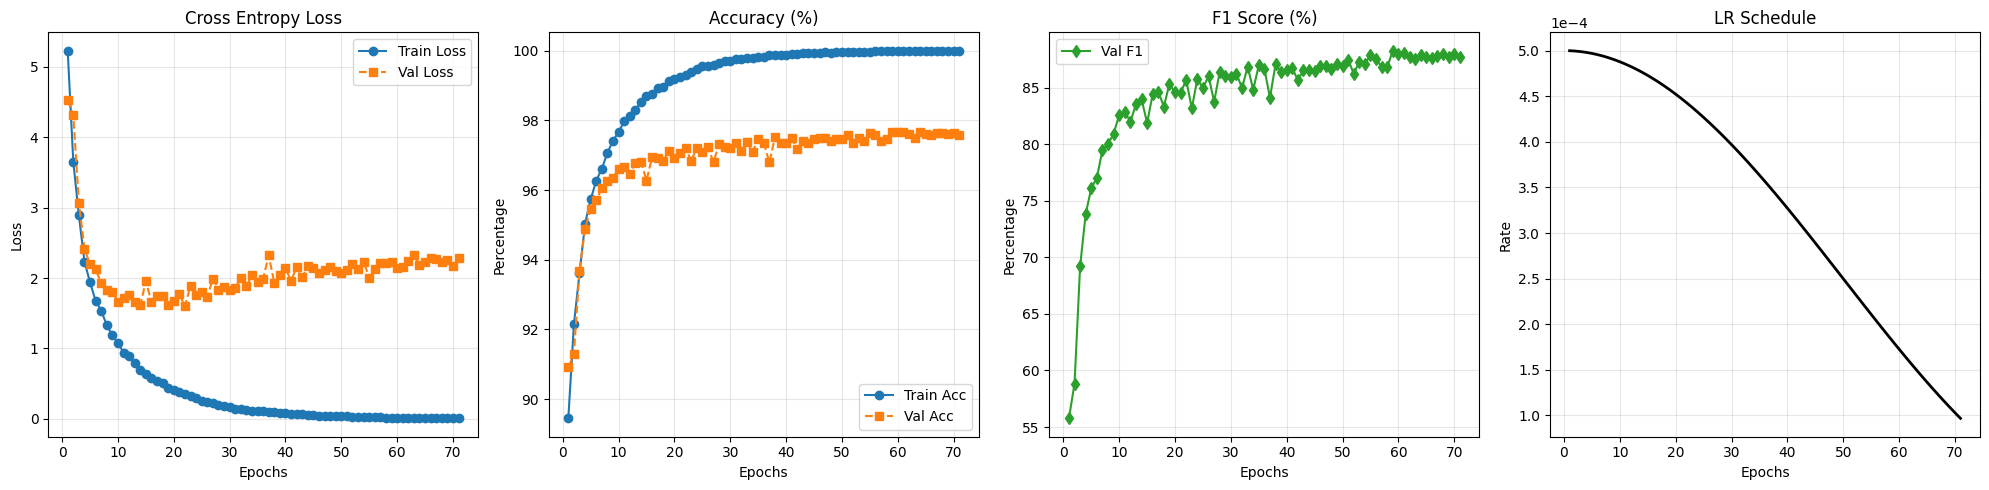

In [51]:
# Visualize & Audit
plot_history(history)


             FINAL TEST SET AUDIT              
Loss: 0.0032 | Accuracy: 100.00% | Macro F1: 100.00%

Classification Report (Hide Outside=True):

              precision    recall  f1-score   support

       B-PER       1.00      1.00      1.00         1
       I-PER       1.00      1.00      1.00         1
       B-ORG       1.00      1.00      1.00         2
       I-ORG       1.00      1.00      1.00         1
       B-LOC       1.00      1.00      1.00         1
       I-LOC       0.00      0.00      0.00         0
      B-MISC       1.00      1.00      1.00         4
      I-MISC       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00        10
   macro avg       0.75      0.75      0.75        10
weighted avg       1.00      1.00      1.00        10



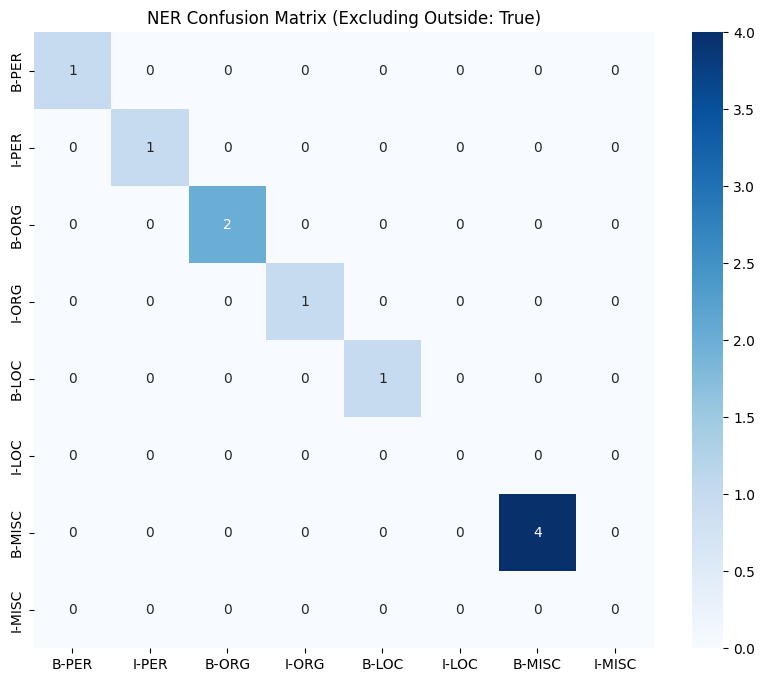


Final Summary | Loss: 0.0032 | Accuracy: 100.00% | F1-score: 100.00%


In [57]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# We set plot=True here to get the Heatmap and Classification Report
test_loss, test_acc, test_f1 = evaluate_model(model_crf, test_loader, DEVICE, tag_names=tag_names, plot=True, hide_outside=True)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Accuracy: {test_acc:.2%} | F1-score: {test_f1:.2%}')
print("="*100)

---
## 4. Model Inference and Sentiment Prediction

---

In [65]:
def predict_ner(model, sentence, vocab, char_vocab, tokenizer, tag_names):
    model.eval()

    # 1. Tokenize
    tokens = tokenizer(sentence)
    
    # 2. Word Numericalization [1, Seq_Len]
    word_ids = [vocab.get(t.lower(), 1) for t in tokens]
    
    # 3. Char Numericalization [1, Seq_Len, Max_Word_Len]
    # This must match your training MAX_WORD_LEN (e.g., 15)
    MAX_WORD_LEN = 15 
    char_ids_list = []
    for word in tokens:
        c_ids = [char_vocab.get(c, 1) for c in word][:MAX_WORD_LEN]
        c_ids += [0] * (MAX_WORD_LEN - len(c_ids))
        char_ids_list.append(c_ids)

    # 4. Prepare Tensors
    word_tensor = torch.LongTensor(word_ids).unsqueeze(0).to(DEVICE)
    char_tensor = torch.LongTensor(char_ids_list).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(word_ids)]).to(DEVICE)

    with torch.no_grad():
        # Pass both word and char tensors to the model
        prediction_indices = model(word_tensor, char_tensor, length)[0]

    # 5. Map back to tag names
    predicted_tags = [tag_names[idx] for idx in prediction_indices]
    
    return list(zip(tokens, predicted_tags))


# ================================================================================
def run_ner_test_suite(model, tests, vocab, char_vocab, tokenizer, tag_names):
    for text in tests:
        print(f"\nSentence: {text}")
        results = predict_ner(model, text, vocab, char_vocab, tokenizer, tag_names)
        
        # Merging Logic (B-PER + I-PER -> PER)
        merged_entities = []
        current_entity = None
        
        for word, tag in results:
            if tag.startswith("B-"):
                if current_entity: merged_entities.append(current_entity)
                current_entity = {"text": word, "type": tag[2:]}
            elif tag.startswith("I-") and current_entity and tag[2:] == current_entity["type"]:
                current_entity["text"] += f" {word}"
            else:
                if current_entity: merged_entities.append(current_entity)
                current_entity = None
        if current_entity: merged_entities.append(current_entity)

        if merged_entities:
            print(f"{'Entity':<25} | {'Type':<10}")
            print("-" * 40)
            for ent in merged_entities:
                print(f"{ent['text']:<25} | {ent['type']:<10}")
        else:
            print("No entities detected.")

In [67]:
# Simple robust tokenizer that splits on spaces and punctuation
def tokenizer(text):
    # This regex pulls words and punctuation out as individual tokens
    return re.findall(r"[\w']+|[.,!?;-]", text)

# Now your test suite will run correctly
test_sentences = [
    "Manchester United will play Tottenham in London this Saturday.",
    "The European Commission met in Brussels to discuss the economy.",
    "Elon Musk announced a new project in California."
]

run_ner_test_suite(model_crf, test_sentences, vocab, char_vocab, tokenizer, tag_names)


Sentence: Manchester United will play Tottenham in London this Saturday.
Entity                    | Type      
----------------------------------------
Manchester United         | ORG       
Tottenham                 | ORG       
London                    | LOC       

Sentence: The European Commission met in Brussels to discuss the economy.
Entity                    | Type      
----------------------------------------
European Commission       | ORG       
Brussels                  | LOC       

Sentence: Elon Musk announced a new project in California.
Entity                    | Type      
----------------------------------------
Elon Musk                 | ORG       
California                | LOC       


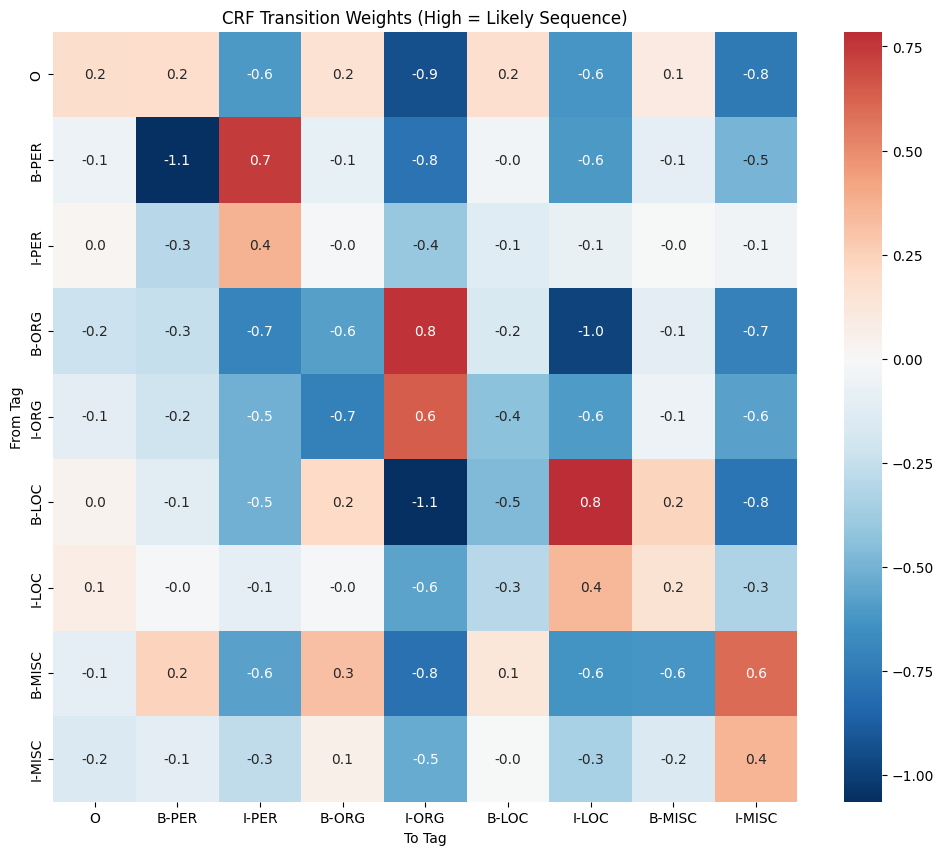

In [60]:
def plot_transitions(model, tag_names):
    # Extract the transition matrix from the CRF layer
    # Shape: [num_tags, num_tags]
    transitions = model.crf.transitions.detach().cpu().numpy()
    
    df = pd.DataFrame(transitions, index=tag_names, columns=tag_names)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df, annot=True, fmt=".1f", cmap="RdBu_r", center=0)
    plt.title("CRF Transition Weights (High = Likely Sequence)")
    plt.xlabel("To Tag")
    plt.ylabel("From Tag")
    plt.show()

plot_transitions(model_crf, tag_names)

In [69]:
def audit_crf_transitions(model, tag_names):
    # Extract the transition matrix [num_tags, num_tags]
    # transitions[i, j] is the score for transitioning from tag i to tag j
    transitions = model.crf.transitions.data.cpu().numpy()
    
    all_pairs = []
    for i in range(len(tag_names)):
        for j in range(len(tag_names)):
            all_pairs.append((tag_names[i], tag_names[j], transitions[i, j]))
            
    # Sort by weight
    all_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print(f"{'From':<10} -> {'To':<10} | {'Weight':<8}")
    print("-" * 35)
    print("TOP 5 LIKELY TRANSITIONS (Grammar Rules)")
    for f, t, w in all_pairs[:5]:
        print(f"{f:<10} -> {t:<10} | {w:.4f}")
        
    print("\nTOP 5 FORBIDDEN TRANSITIONS (Illegal Jumps)")
    for f, t, w in all_pairs[-5:]:
        print(f"{f:<10} -> {t:<10} | {w:.4f}")

audit_crf_transitions(model_crf, tag_names)

From       -> To         | Weight  
-----------------------------------
TOP 5 LIKELY TRANSITIONS (Grammar Rules)
B-LOC      -> I-LOC      | 0.7854
B-ORG      -> I-ORG      | 0.7643
B-PER      -> I-PER      | 0.7356
I-ORG      -> I-ORG      | 0.6434
B-MISC     -> I-MISC     | 0.6002

TOP 5 FORBIDDEN TRANSITIONS (Illegal Jumps)
B-MISC     -> I-ORG      | -0.7904
O          -> I-ORG      | -0.9273
B-ORG      -> I-LOC      | -0.9799
B-PER      -> B-PER      | -1.0533
B-LOC      -> I-ORG      | -1.0641


---

## The NER Audit Suite
---

This class encapsulates the Preprocessing, Inference, and Audit (Heatmaps/Transitions) in one place

---

In [70]:
class NERAuditSuite:
    def __init__(self, model, vocab, char_vocab, tag_names, device):
        self.model = model.to(device)
        self.vocab = vocab
        self.char_vocab = char_vocab
        self.tag_names = tag_names
        self.device = device
        self.max_word_len = 15 # Consistent with training

    def _prepare_tensors(self, tokens):
        """Internal helper to convert raw tokens to 3D tensors."""
        word_ids = [self.vocab.get(t.lower(), 1) for t in tokens]
        
        char_ids_list = []
        for word in tokens:
            c_ids = [self.char_vocab.get(c, 1) for c in word][:self.max_word_len]
            c_ids += [0] * (self.max_word_len - len(c_ids))
            char_ids_list.append(c_ids)

        word_tensor = torch.LongTensor(word_ids).unsqueeze(0).to(self.device)
        char_tensor = torch.LongTensor(char_ids_list).unsqueeze(0).to(self.device)
        length = torch.LongTensor([len(word_ids)]).to(self.device)
        
        return word_tensor, char_tensor, length

    def predict(self, sentence, tokenizer, merge_entities=True):
        self.model.eval()
        tokens = tokenizer(sentence)
        w_tensor, c_tensor, length = self._prepare_tensors(tokens)

        with torch.no_grad():
            prediction_indices = self.model(w_tensor, c_tensor, length)[0]
        
        predicted_tags = [self.tag_names[idx] for idx in prediction_indices]
        results = list(zip(tokens, predicted_tags))

        if not merge_entities:
            return results

        # Merging Logic (B-PER + I-PER -> PER)
        merged = []
        curr = None
        for word, tag in results:
            if tag.startswith("B-"):
                if curr: merged.append(curr)
                curr = {"text": word, "type": tag[2:]}
            elif tag.startswith("I-") and curr and tag[2:] == curr["type"]:
                curr["text"] += f" {word}"
            else:
                if curr: merged.append(curr)
                curr = None
        if curr: merged.append(curr)
        return merged

    def print_report(self, tests, tokenizer):
        """Prints a clean CLI-ready report of test sentences."""
        for text in tests:
            print(f"\nSentence: {text}")
            entities = self.predict(text, tokenizer)
            if entities:
                print(f"{'Entity':<25} | {'Type':<10}")
                print("-" * 40)
                for ent in entities:
                    print(f"{ent['text']:<25} | {ent['type']:<10}")
            else:
                print("No entities detected.")

    def plot_crf_logic(self):
        """Visualizes the transition grammar learned by the CRF."""
        transitions = self.model.crf.transitions.data.cpu().numpy()
        plt.figure(figsize=(10, 8))
        sns.heatmap(transitions, annot=True, fmt=".1f", cmap="RdBu_r",
                    xticklabels=self.tag_names, yticklabels=self.tag_names)
        plt.title("CRF Transition Matrix (Learned Grammar)")
        plt.show()


Sentence: Manchester United will play Tottenham in London this Saturday.
Entity                    | Type      
----------------------------------------
Manchester United         | ORG       
Tottenham                 | ORG       
London                    | LOC       

Sentence: The European Commission met in Brussels to discuss the economy.
Entity                    | Type      
----------------------------------------
European Commission       | ORG       
Brussels                  | LOC       

Sentence: Elon Musk announced a new project in California.
Entity                    | Type      
----------------------------------------
Elon Musk                 | ORG       
California                | LOC       


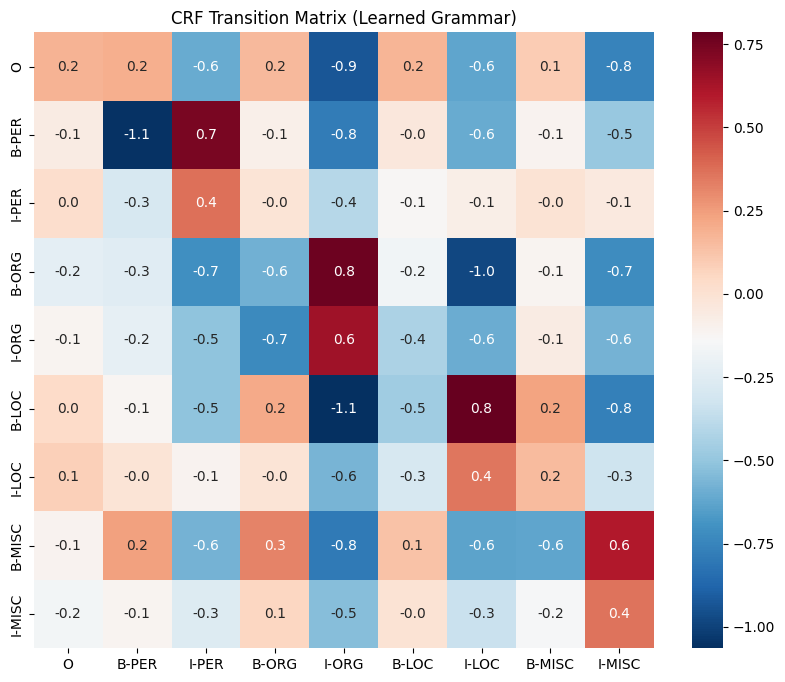

In [72]:
# Assuming model, vocab, char_vocab, and tag_names are loaded
audit = NERAuditSuite(model_crf, vocab, char_vocab, tag_names, DEVICE)

# Run tests
audit.print_report(test_sentences, tokenizer)

# Audit the 'brain'
audit.plot_crf_logic()

In [68]:
%watermark -iv

datasets   : 4.8.3
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchcrf   : 0.7.2
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

